# Logistic Regression

Harika, sınıflandırma modellerinin ilk ve en temeli olan **Logistic Regression** konusuna geldin. Adı “regression” olsa da bu model aslında **sınıflandırma için kullanılır**. Şimdi sana sade, net ve sağlam bir ön bilgi vereyim:

---

## 🟦 Logistic Regression (Lojistik Regresyon)

### 📌 Tanım:

Logistic Regression, bir gözlemin belirli bir sınıfa ait olma **olasılığını tahmin eden** istatistiksel bir modeldir.

> Yani sürekli bir sayı yerine:
> ❓“Bu veri 1 mi yoksa 0 mı?” gibi **ikili (binary) sınıflama** yapar.

---

## 🧠 Neden “Regression” Deniyor?

Çünkü:

* Modelin içinde **linear regression** benzeri bir yapı var: `b0 + b1*X`
* Ama bu sonucu, doğrusal bir değer olarak bırakmıyoruz, onun üzerinden bir **dönüşüm (sigmoid)** geçiriyoruz.

---

## 🧮 Temel Formül:

```
P(Y=1 | X) = 1 / (1 + e^-(b0 + b1*X))
```

Bu, **sigmoid (lojistik) fonksiyonudur**.

* Girdi: `z = b0 + b1*X`
* Çıktı: 0 ile 1 arasında bir olasılık değeri
* Bu değeri 0.5 ile karşılaştırarak sınıf kararını veririz:

  * ≥ 0.5 → sınıf 1
  * < 0.5 → sınıf 0

---

## 📈 Sigmoid Fonksiyonun Şekli

```
           1
          ┤
          │       ●
          │      ●
          │    ●
     0.5 ─┼──────●────────
          │   ●
          │ ●
          │
          └────────────→
             (b0 + b1*X)
```

Ortadaki eşik değeri 0.5’tir. Bu eşik sınıflandırma kararını verir.

---

## 🎯 Nerede Kullanılır?

* Evet/Hayır problemleri (binary classification)
* Örnekler:

  * Müşteri ayrılacak mı? (`0: kalıyor`, `1: ayrılıyor`)
  * Mail spam mi değil mi?
  * Hastada kanser var mı?

---

## ✅ Avantajları:

* **Hızlı ve basit** bir modeldir.
* **Çıktısı olasılıktır** → yorumlamak kolaydır.
* **Ağırlıklar** sayesinde değişken etkisi anlaşılır.

---

## ⚠️ Sınırlamaları:

* Sadece **doğrusal sınırlara sahip verilerde** iyi çalışır.
* Karmaşık sınıflama problemlerinde (non-linear) başarısı düşer.
* Genellikle **baseline model** olarak kullanılır.

---

## 📊 Logistic vs Linear Regression

| Özellik        | Linear Regression        | Logistic Regression               |
| -------------- | ------------------------ | --------------------------------- |
| Hedef değişken | Sürekli sayı             | 0-1 (kategorik)                   |
| Tahmin çıktısı | Herhangi bir reel sayı   | 0-1 arasında olasılık             |
| Kullanım amacı | Sayı tahmini (regresyon) | Sınıf tahmini (sınıflandırma)     |
| Aktivasyon yok | Doğrudan çıktı verir     | Sigmoid fonksiyonu ile dönüştürür |

---

## 💻 Python'da Logistic Regression Örneği:

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

## 🧠 Ekstra:

Modelin doğruluğunu değerlendirmek için:

* Confusion Matrix (karmaşıklık matrisi)
* Accuracy, Precision, Recall, F1-Score
* ROC-AUC gibi metrikler kullanılır (ilerleyen videolarda gelecek)

---

## 🎓 Özetle:

* Logistic Regression, **sınıflandırma problemlerinde temel modeldir**.
* Model, doğrusal regresyonu alır ama sonuçları **sigmoid fonksiyonu** ile sınırlayıp **olasılık** üretir.
* Basit, hızlı, yorumlanabilir bir modeldir.

---

📊 Logistic Regression ve MLE Arasındaki Bağlantı

Linear Regression’da:
* Hedef: Hataların karesini minimize etmek (least squares)
  
Logistic Regression’da:
* Hedef: Olasılığı maksimize etmek
* (çünkü çıktı 0 veya 1 → yani olay ya olur ya olmaz)

Bu yüzden Logistic Regression’da "hataları minimize etmek" yerine "olasılığı maksimize ederiz"
→ İşte burada Maximum Likelihood devreye girer.

Şimdi bir otomobil şirketi yeni bir otomobil piyasaya sürmüş olsun ve hangi eski müşterilerin bu ürünü alma mihtimali yüksek olacağını tahmin etmeni istiyor, verilerde yaş tahmini maaş ve önceden suv alan veya almayanlar 0 1 olarak

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

In [4]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values #son sütunu almadık features 2 sütunda
y = dataset.iloc[:, -1].values #dependent variable son sütunda onu aldık

## Verisetini train ve test olarak ayırıyoruz
Splitting the dataset into the training set and test set

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=0)

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [7]:
print(X_train)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

In [8]:
print(X_test)

[[-0.80480212  0.50496393]
 [-0.01254409 -0.5677824 ]
 [-0.30964085  0.1570462 ]
 [-0.80480212  0.27301877]
 [-0.30964085 -0.5677824 ]
 [-1.10189888 -1.43757673]
 [-0.70576986 -1.58254245]
 [-0.21060859  2.15757314]
 [-1.99318916 -0.04590581]
 [ 0.8787462  -0.77073441]
 [-0.80480212 -0.59677555]
 [-1.00286662 -0.42281668]
 [-0.11157634 -0.42281668]
 [ 0.08648817  0.21503249]
 [-1.79512465  0.47597078]
 [-0.60673761  1.37475825]
 [-0.11157634  0.21503249]
 [-1.89415691  0.44697764]
 [ 1.67100423  1.75166912]
 [-0.30964085 -1.37959044]
 [-0.30964085 -0.65476184]
 [ 0.8787462   2.15757314]
 [ 0.28455268 -0.53878926]
 [ 0.8787462   1.02684052]
 [-1.49802789 -1.20563157]
 [ 1.07681071  2.07059371]
 [-1.00286662  0.50496393]
 [-0.90383437  0.30201192]
 [-0.11157634 -0.21986468]
 [-0.60673761  0.47597078]
 [-1.6960924   0.53395707]
 [-0.11157634  0.27301877]
 [ 1.86906873 -0.27785096]
 [-0.11157634 -0.48080297]
 [-1.39899564 -0.33583725]
 [-1.99318916 -0.50979612]
 [-1.59706014  0.33100506]
 

In [9]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train,y_train) #

LogisticRegression(random_state=0)

In [10]:
print(classifier.predict(sc.transform([[30,87000]]))) #sc standardscaler burada
#print(classifier.predict_log_proba(sc.transform([[30,87000]]))) #
#print(classifier.predict_proba(sc.transform([[30,87000]]))) #

[0]


## Test setinden tahminler üretmek
Predicting the Test set results
Bu veristetinde birden fazla bağımsız değişken vardır özellikler x de

In [11]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))
#ilk sütun tahmin edilen değerler sağda ise gerçek değerler

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]]


# Karmaşa Matrisi Oluşturma
Making the Confusion Matrix

Harika! Şimdi sınıflandırma modellerini değerlendirirken çok sık kullanacağımız **confusion matrix** ve **accuracy score** konularına geldin. Bu metrikler, modelin **ne kadar doğru tahmin yaptığını ve nerede hata yaptığını** anlamana yardımcı olur.

Hemen sade ve uygulamaya yönelik şekilde açıklayayım:

---

## 📊 1. **Confusion Matrix (Karmaşıklık Matrisi)**

### 📌 Tanım:

Confusion Matrix, modelin yaptığı **doğru ve yanlış sınıflandırmaları tablo şeklinde gösteren** bir yapıdır.

### 🧱 Şekli:

İkili (binary) sınıflandırma için klasik yapısı:

|                     | **Gerçek Pozitif (1)** | **Gerçek Negatif (0)** |
| ------------------- | ---------------------- | ---------------------- |
| **Tahmin: Pozitif** | TP (True Positive)     | FP (False Positive)    |
| **Tahmin: Negatif** | FN (False Negative)    | TN (True Negative)     |

---

### 📌 Açıklamaları:

| Terim | Anlamı                                                                |
| ----- | --------------------------------------------------------------------- |
| TP    | Gerçek sınıf 1, model de 1 tahmin etti (doğru)                        |
| TN    | Gerçek sınıf 0, model de 0 tahmin etti (doğru)                        |
| FP    | Gerçek sınıf 0, ama model 1 dedi (yanlış pozitif — yanlış alarm)      |
| FN    | Gerçek sınıf 1, ama model 0 dedi (yanlış negatif — gözden kaçan vaka) |

---

### 💻 Python Örneği:

```python
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 0, 1, 0, 1]
y_pred = [1, 0, 1, 0, 0, 1, 1]

cm = confusion_matrix(y_true, y_pred)
print(cm)
```

Çıktı örneği:

```
[[2 1]
 [1 3]]
```

* TN = 2, FP = 1
* FN = 1, TP = 3

---

## ✅ 2. **Accuracy Score (Doğruluk Skoru)**

### 📌 Tanım:

Modelin yaptığı **doğru tahminlerin oranıdır**. En basit ama bazen yanıltıcı metrik olabilir.

```
Accuracy = (TP + TN) / Tüm tahmin sayısı
```

### 💻 Python Örneği:

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")
```

---

## ⚠️ Accuracy Neden Yetersiz Olabilir?

Örneğin:

* Verinin %95’i sınıf 0
* Model hep “0” dese bile `accuracy = 95%` çıkar
* Ama bu model **1’leri tamamen gözden kaçırır**

**Bu nedenle**, `confusion_matrix` ile birlikte aşağıdaki metrikler de kullanılır (ilerleyen videolarda gelecektir):

* **Precision**: Ne kadar doğru pozitif tahmin yaptın?
* **Recall**: Pozitifleri ne kadar yakalayabildin?
* **F1-Score**: Precision ve Recall’un dengesi

---

## 🎓 Özetle:

| Metrik           | Ne Gösterir?                                                  |
| ---------------- | ------------------------------------------------------------- |
| Confusion Matrix | Hangi sınıfları doğru/yanlış tahmin ettiğini detaylı gösterir |
| Accuracy Score   | Toplam tahminlerin ne kadarını doğru yaptığını gösterir       |

---

Video sonunda istersen confusion matrix çıktısını yorumlamayı da birlikte yaparız.
Bir sonraki adımda `precision`, `recall`, `f1` gibi metrikler gelecektir. Hazır olduğunda onları da açıklayayım mı?


In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred) #gerçek sonuçları ve tahmin edilenleri veriyoruz
print(cm)
accuracy_score(y_test, y_pred) #aynı şeyi accuracy score için

[[65  3]
 [ 8 24]]


0.89

## Eğitim seti sonuçlarının görselleştirilmesi
Visualising the Training set results
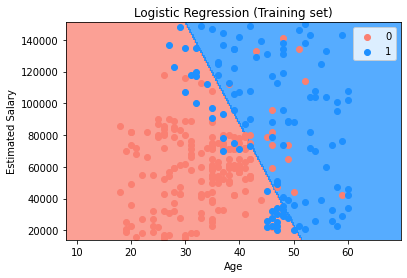

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results
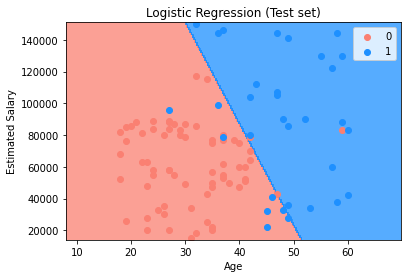


In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()